In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass
        # print(os.path.join(dirname, filename))
print("done")
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

done


In [6]:
try:
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import confusion_matrix, classification_report
    from sklearn.model_selection import train_test_split
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader,Dataset,random_split
    from torchvision import transforms
    from torchvision.datasets import ImageFolder
    import torch.optim as optim
    import timm
    from PIL import Image
    import torchvision
    
    print("All imports successful")
except Exception as e:
    print(f"Error during imports: {str(e)}")

All imports successful


In [7]:
try:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    if device == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
except Exception as e:
    print(f"Error checking GPU: {str(e)}")

Using device: cuda


In [8]:
try:
    # Define paths
    data_dir = '/kaggle/input/mangoleaf-dataset/dataset'  # Update this path as needed
    print("Dataset contents:", os.listdir(data_dir))
    train_transform = transforms.Compose([
        transforms.Resize((224, 112)),  # First resize maintaining aspect ratio
        transforms.Pad((56, 0, 56, 0)),  # Left, Top, Right, Bottom padding to make 224x224
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    val_transform = transforms.Compose([
        transforms.Resize((224, 112)),
        transforms.Pad((56, 0, 56, 0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    print("Transforms defined successfully")
except Exception as e:
    print(f"Error in preprocessing setup: {str(e)}")

Dataset contents: ['GALL MILDGE', 'ANTHRACNOSE', 'BACTERIAL CRANKER', 'SOOTY MOULD', 'MANGO SOOTY', 'HEALTHY', 'DIEBACK']
Transforms defined successfully


In [9]:

full_dataset = ImageFolder(root=data_dir)
class_names = full_dataset.classes
print("Class names:", class_names)
print("Number of classes:", len(class_names))
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
print(f"train size:{train_size}|val size:{val_size}")
print(f"train type:{type(train_size)}|val type:{type(val_size)}")
train_dataset

Class names: ['ANTHRACNOSE', 'BACTERIAL CRANKER', 'DIEBACK', 'GALL MILDGE', 'HEALTHY', 'MANGO SOOTY', 'SOOTY MOULD']
Number of classes: 7
train size:1436|val size:359
train type:<class 'int'>|val type:<class 'int'>


In [10]:
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
val_dataset.dataset.transform

Compose(
    Resize(size=(224, 112), interpolation=bilinear, max_size=None, antialias=True)
    Pad(padding=(56, 0, 56, 0), fill=0, padding_mode=constant)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

In [11]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")
print("Dataset preparation complete")
train_loader

Training samples: 1436, Validation samples: 359
Dataset preparation complete


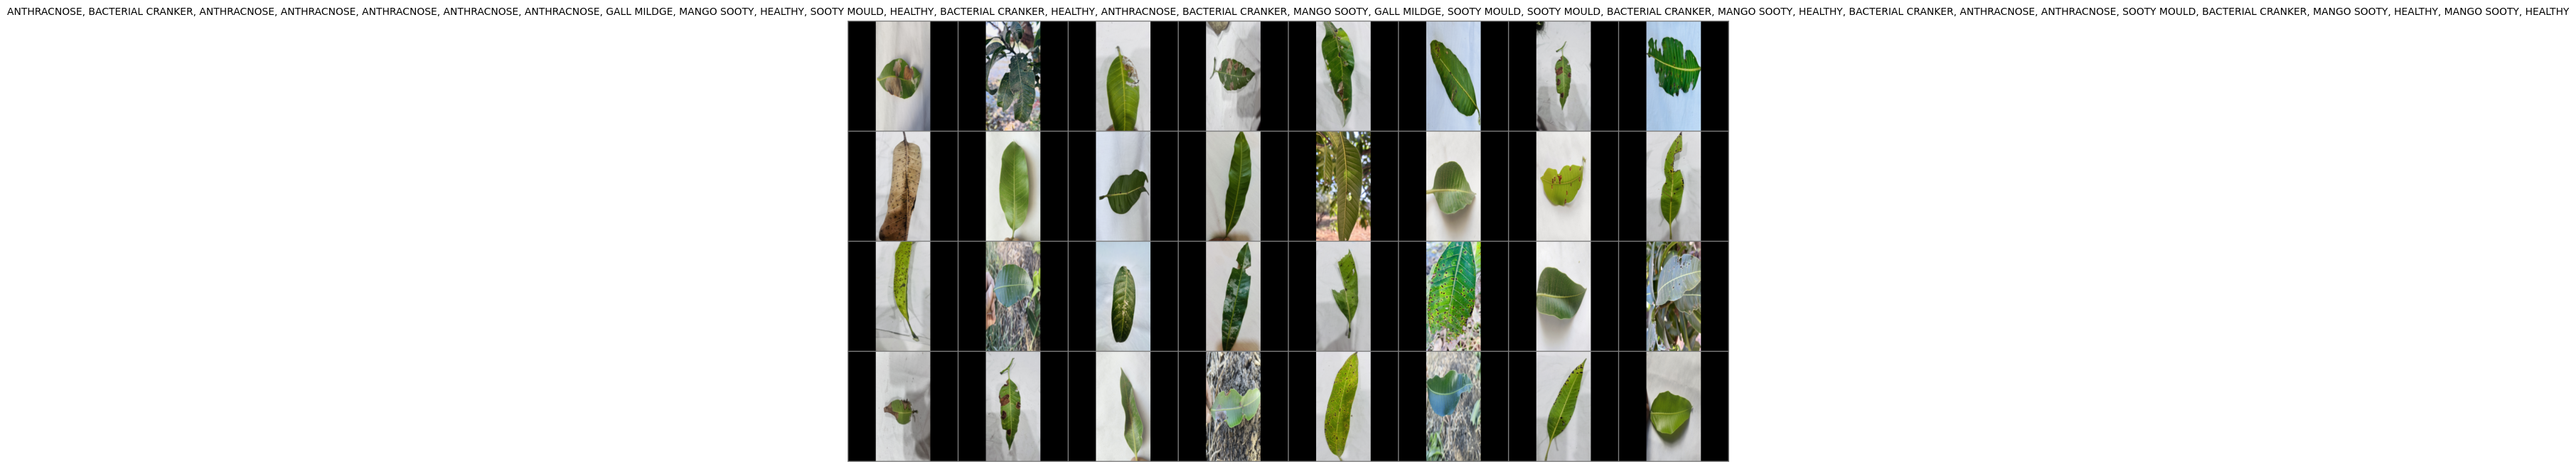

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(inp, title=None):
    """Imshow for Tensor with enhanced visibility."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    plt.figure(figsize=(16, 10))  # Increase figure size
    plt.imshow(inp)
    if title is not None:
        if isinstance(title, list):
            plt.title(", ".join(title), fontsize=10)
        else:
            plt.title(title)
    plt.axis('off')
    plt.pause(0.001)

inputs, classes = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs, nrow=8, padding=2)
imshow(out, title=[class_names[x] for x in classes])

In [13]:
model = timm.create_model('vit_base_patch16_224', pretrained=True)

# Modify the classification head
num_classes = len(class_names)
print(num_classes)
model.head = nn.Linear(model.head.in_features, num_classes)
model = model.to(device)
print("Model architecture:")
print(model)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

7
Model architecture:
VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
   

In [ ]:
num_epochs = 25

In [14]:
num_epochs = 15

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), 
                       lr=0.0005,  # Reduced from 0.001
                       weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, 
                                         max_lr=0.001, 
                                         steps_per_epoch=len(train_loader), 
                                         epochs=num_epochs)
print("Model preparation complete")

Model preparation complete


epoch_loss0.5970687085041428!epoch_acc0.7903899721448469
epoch_loss0.2941521389570741!epoch_acc0.8941504178272981
Epoch 1/15
Train Loss: 0.5971 Acc: 0.7904
Val Loss: 0.2942 Acc: 0.8942
----------
epoch_loss0.12160624150695243!epoch_acc0.9644846796657381
epoch_loss0.25084593921152665!epoch_acc0.9303621169916435
Epoch 2/15
Train Loss: 0.1216 Acc: 0.9645
Val Loss: 0.2508 Acc: 0.9304
----------
epoch_loss0.0584137188452283!epoch_acc0.9825905292479109
epoch_loss0.42379389383666694!epoch_acc0.9164345403899722
Epoch 3/15
Train Loss: 0.0584 Acc: 0.9826
Val Loss: 0.4238 Acc: 0.9164
----------
epoch_loss0.033711067873343804!epoch_acc0.9881615598885793
epoch_loss0.29828787387950567!epoch_acc0.9387186629526463
Epoch 4/15
Train Loss: 0.0337 Acc: 0.9882
Val Loss: 0.2983 Acc: 0.9387
----------
epoch_loss0.03371971831601865!epoch_acc0.9895543175487466
epoch_loss0.21064724372103188!epoch_acc0.9415041782729805
Epoch 5/15
Train Loss: 0.0337 Acc: 0.9896
Val Loss: 0.2106 Acc: 0.9415
----------


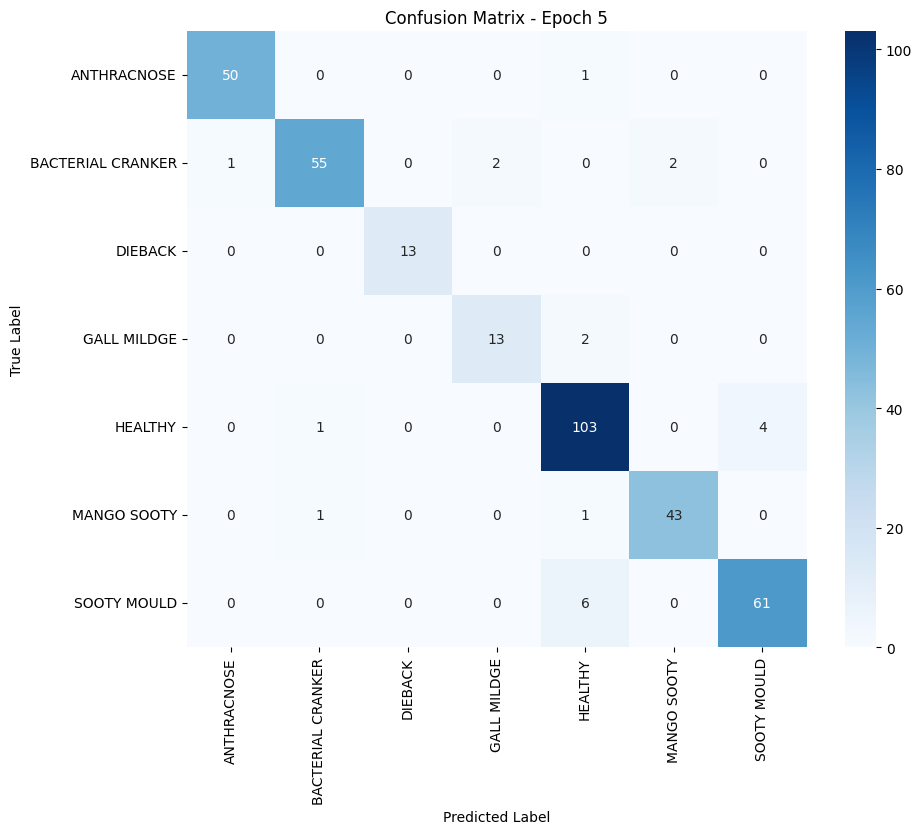

epoch_loss0.02434818897737465!epoch_acc0.9937325905292479
epoch_loss0.36641310325101883!epoch_acc0.9387186629526463
Epoch 6/15
Train Loss: 0.0243 Acc: 0.9937
Val Loss: 0.3664 Acc: 0.9387
----------
epoch_loss0.01847718140252407!epoch_acc0.995125348189415
epoch_loss0.3688932922098028!epoch_acc0.9498607242339833
Epoch 7/15
Train Loss: 0.0185 Acc: 0.9951
Val Loss: 0.3689 Acc: 0.9499
----------
epoch_loss0.009127325152601005!epoch_acc0.9958217270194986
epoch_loss0.41061911007654034!epoch_acc0.924791086350975
Epoch 8/15
Train Loss: 0.0091 Acc: 0.9958
Val Loss: 0.4106 Acc: 0.9248
----------
epoch_loss0.020753989488075806!epoch_acc0.9937325905292479
epoch_loss0.4298387476811211!epoch_acc0.9192200557103064
Epoch 9/15
Train Loss: 0.0208 Acc: 0.9937
Val Loss: 0.4298 Acc: 0.9192
----------
epoch_loss0.023816486277415165!epoch_acc0.9937325905292479
epoch_loss0.6061976701274333!epoch_acc0.8997214484679665
Epoch 10/15
Train Loss: 0.0238 Acc: 0.9937
Val Loss: 0.6062 Acc: 0.8997
----------


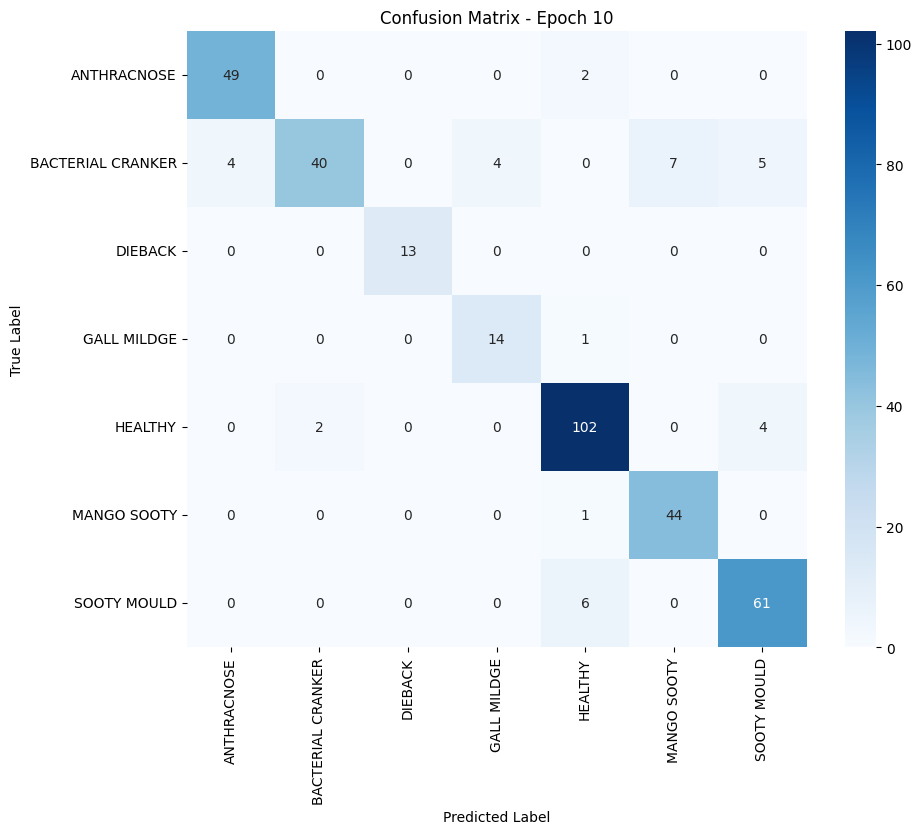

epoch_loss0.05420125597013903!epoch_acc0.9818941504178273
epoch_loss0.5988920959423512!epoch_acc0.8607242339832869
Epoch 11/15
Train Loss: 0.0542 Acc: 0.9819
Val Loss: 0.5989 Acc: 0.8607
----------
epoch_loss0.11108173385864346!epoch_acc0.9644846796657381
epoch_loss0.32354959154444485!epoch_acc0.9052924791086351
Epoch 12/15
Train Loss: 0.1111 Acc: 0.9645
Val Loss: 0.3235 Acc: 0.9053
----------
epoch_loss0.09030065447880697!epoch_acc0.967966573816156
epoch_loss0.5514323904793865!epoch_acc0.8607242339832869
Epoch 13/15
Train Loss: 0.0903 Acc: 0.9680
Val Loss: 0.5514 Acc: 0.8607
----------
epoch_loss0.09368072978083387!epoch_acc0.9749303621169917
epoch_loss0.34507618660579403!epoch_acc0.9192200557103064
Epoch 14/15
Train Loss: 0.0937 Acc: 0.9749
Val Loss: 0.3451 Acc: 0.9192
----------
epoch_loss0.0448885711096746!epoch_acc0.9846796657381616
epoch_loss0.39934609168887525!epoch_acc0.9136490250696379
Epoch 15/15
Train Loss: 0.0449 Acc: 0.9847
Val Loss: 0.3993 Acc: 0.9136
----------


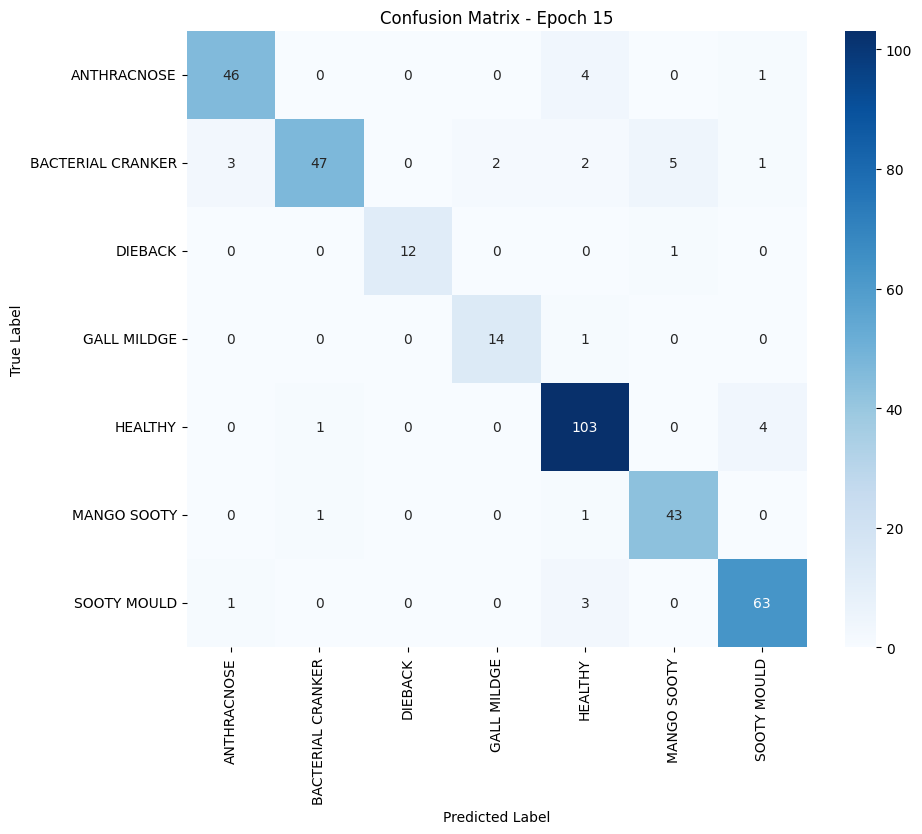

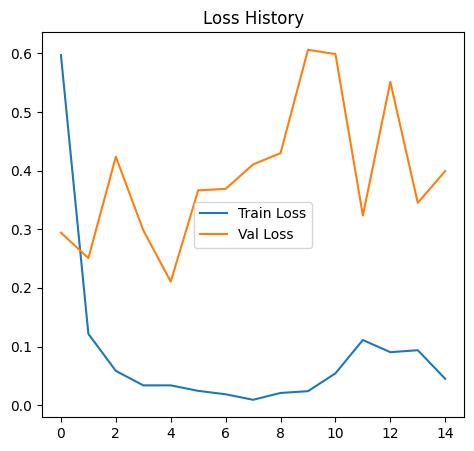

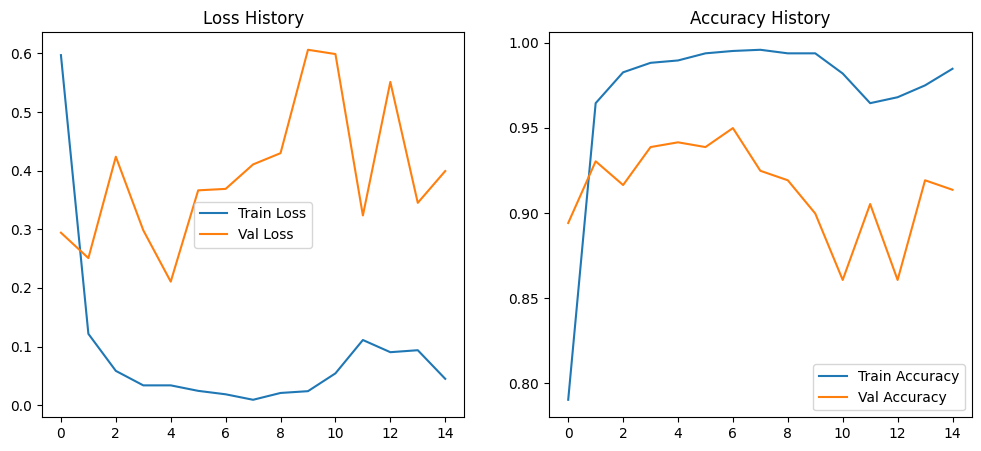

In [16]:
# Section 5: Training Loop
try:

    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss / len(train_dataset)
        epoch_acc = running_corrects.double() / len(train_dataset)
        print(f"epoch_loss{epoch_loss}!epoch_acc{epoch_acc}")
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)
        
        # Validation phase
        model.eval()
        val_running_loss = 0.0
        val_running_corrects = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item() * inputs.size(0)
                val_running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_epoch_loss = val_running_loss / len(val_dataset)
        val_epoch_acc = val_running_corrects.double() / len(val_dataset)
        print(f"epoch_loss{val_epoch_loss}!epoch_acc{val_epoch_acc}")
        val_loss_history.append(val_epoch_loss)
        val_acc_history.append(val_epoch_acc)
        
        # Update learning rate
        scheduler.step()
        
        # Print epoch results
        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}')
        print('-' * 10)
        
        # Print confusion matrix every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == num_epochs - 1:
            cm = confusion_matrix(all_labels, all_preds)
            plt.figure(figsize=(10, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                        xticklabels=class_names, 
                        yticklabels=class_names)
            plt.title(f'Confusion Matrix - Epoch {epoch+1}')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.show()
    
    # Plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Val Loss')
    plt.title('Loss History')
    plt.legend()
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Val Loss')
    plt.title('Loss History')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    # Convert tensors to numpy arrays if they're on GPU
    plt.plot([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in train_acc_history], 
             label='Train Accuracy')
    plt.plot([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in val_acc_history], 
             label='Val Accuracy')
    plt.title('Accuracy History')
    plt.legend()
    
    plt.show()
    
except Exception as e:
    print(f"Error during training: {str(e)}")

In [24]:
# %% [code]
# Robust Attention Visualization with Error Handling
try:
    import numpy as np
    import matplotlib.pyplot as plt
    from PIL import Image
    import torch.nn.functional as F

    def visualize_attention_map(model, dataloader, class_names, device, layer_idx=-1, head_idx=None):
        """
        Robust attention visualization with comprehensive error handling
        
        Args:
            model: Pretrained ViT model
            dataloader: Validation dataloader
            class_names: List of class names
            device: CUDA/CPU device
            layer_idx: Which transformer layer to visualize
            head_idx: Which attention head to visualize (None for average)
        """
        # 1. Find a correctly classified sample
        model.eval()
        sample_found = False
        sample_input = None
        sample_label = None
        sample_pred = None
        
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                
                correct_mask = preds == labels
                if correct_mask.any():
                    idx = torch.nonzero(correct_mask)[0].item()
                    sample_input = inputs[idx]
                    sample_label = labels[idx]
                    sample_pred = preds[idx]
                    sample_found = True
                    break
        
        if not sample_found:
            print("No correctly classified samples found in the first batch! Trying more batches...")
            # Try 3 more batches if needed
            for _ in range(3):
                try:
                    inputs, labels = next(dataloader)
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    correct_mask = preds == labels
                    if correct_mask.any():
                        idx = torch.nonzero(correct_mask)[0].item()
                        sample_input = inputs[idx]
                        sample_label = labels[idx]
                        sample_pred = preds[idx]
                        sample_found = True
                        break
                except StopIteration:
                    break
            
            if not sample_found:
                raise ValueError("No correctly classified samples found in validation set!")

        # 2. Register hook properly
        attention_weights = []
        
        def hook_fn(module, input, output):
            if len(output) >= 2:  # Check if attention weights exist in output
                attention_weights.append(output[1].detach())
            else:
                attention_weights.append(None)
        
        # Verify layer index is valid
        if layer_idx < -len(model.blocks) or layer_idx >= len(model.blocks):
            raise ValueError(f"Invalid layer index {layer_idx}. Model has {len(model.blocks)} layers.")
        
        transformer_block = model.blocks[layer_idx]
        if not hasattr(transformer_block.attn, 'attn_drop'):
            raise AttributeError("Model attention structure doesn't match expected ViT architecture")
        
        hook = transformer_block.attn.attn_drop.register_forward_hook(hook_fn)
        
        # 3. Forward pass with the single sample
        with torch.no_grad():
            try:
                _ = model(sample_input.unsqueeze(0))
            except Exception as e:
                hook.remove()
                raise RuntimeError(f"Forward pass failed: {str(e)}")
        
        hook.remove()
        
        # 4. Verify we captured attention weights
        if not attention_weights or attention_weights[0] is None:
            raise RuntimeError("Failed to capture attention weights. Model architecture may be incompatible.")
        
        attn = attention_weights[0].squeeze(0)
        
        # 5. Process attention weights with validation
        if attn.dim() != 3:
            raise RuntimeError(f"Unexpected attention weights shape: {attn.shape}. Expected (num_heads, num_patches+1, num_patches+1)")
        
        num_heads = attn.shape[0]
        if head_idx is not None and (head_idx < 0 or head_idx >= num_heads):
            raise ValueError(f"Invalid head index {head_idx}. Model has {num_heads} attention heads.")
        
        # Select attention head(s)
        if head_idx is not None:
            attn = attn[head_idx]  # Specific head
        else:
            attn = attn.mean(dim=0)  # Average all heads
        
        # Get CLS token attention
        cls_attn = attn[0, 1:]  # Skip CLS token itself
        
        # 6. Reshape and resize attention
        num_patches = cls_attn.shape[0]
        grid_size = int(np.sqrt(num_patches))
        if grid_size * grid_size != num_patches:
            raise RuntimeError(f"Can't reshape {num_patches} patches into square grid")
        
        cls_attn = cls_attn.reshape(grid_size, grid_size)
        
        # Resize to match input image dimensions
        cls_attn = F.interpolate(
            cls_attn.unsqueeze(0).unsqueeze(0).float(),
            size=(224, 224),
            mode='bicubic'
        ).squeeze().cpu().numpy()
        
        # 7. Prepare visualization
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
        
        # Original image
        img = sample_input.cpu().numpy().transpose((1, 2, 0))
        img = img * np.array([0.5, 0.5, 0.5]) + np.array([0.5, 0.5, 0.5])
        img = np.clip(img, 0, 1)
        
        ax1.imshow(img)
        ax1.set_title(f"Original Image\nTrue: {class_names[sample_label]}\nPred: {class_names[sample_pred]}")
        ax1.axis('off')
        
        # Attention heatmap
        im = ax2.imshow(cls_attn, cmap='viridis')
        ax2.set_title(f"Attention Map\nLayer {layer_idx}" + (f", Head {head_idx}" if head_idx is not None else ""))
        ax2.axis('off')
        fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
        
        # Overlay
        ax3.imshow(img)
        ax3.imshow(cls_attn, cmap='viridis', alpha=0.4)
        ax3.set_title("Attention Overlay")
        ax3.axis('off')
        
        plt.tight_layout()
        plt.show()
        
        return cls_attn

    # Example usage with error handling
    try:
        attention_map = visualize_attention_map(
            model=model,
            dataloader=val_loader,
            class_names=class_names,
            device=device,
            layer_idx=6,  # Middle layer
            head_idx=None  # Average all heads
        )
    except Exception as e:
        print(f"Visualization failed: {str(e)}")
        print("Trying with default parameters...")
        try:
            attention_map = visualize_attention_map(
                model=model,
                dataloader=val_loader,
                class_names=class_names,
                device=device
            )
        except Exception as fallback_error:
            print(f"Fallback visualization also failed: {str(fallback_error)}")
            print("Please check your model architecture.")

except Exception as e:
    print(f"Error setting up attention visualization: {str(e)}")

Visualization failed: Failed to capture attention weights. Model architecture may be incompatible.
Trying with default parameters...
Fallback visualization also failed: Failed to capture attention weights. Model architecture may be incompatible.
Please check your model architecture.


In [ ]:
try:
    # Generate classification report
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Display sample predictions
    def visualize_predictions(loader, model, class_names, num_images=10):
        model.eval()
        images_so_far = 0
        plt.figure(figsize=(15, 10))
        
        with torch.no_grad():
            for inputs, labels in loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                
                for j in range(inputs.size()[0]):
                    images_so_far += 1
                    ax = plt.subplot(2, 5, images_so_far)
                    ax.axis('off')
                    ax.set_title(f'Pred: {class_names[preds[j]]}\nTrue: {class_names[labels[j]]}')
                    imshow(inputs.cpu().data[j])
                    
                    if images_so_far == num_images:
                        return
    
    visualize_predictions(val_loader, model, class_names)
    
except Exception as e:
    print(f"Error during evaluation: {str(e)}")

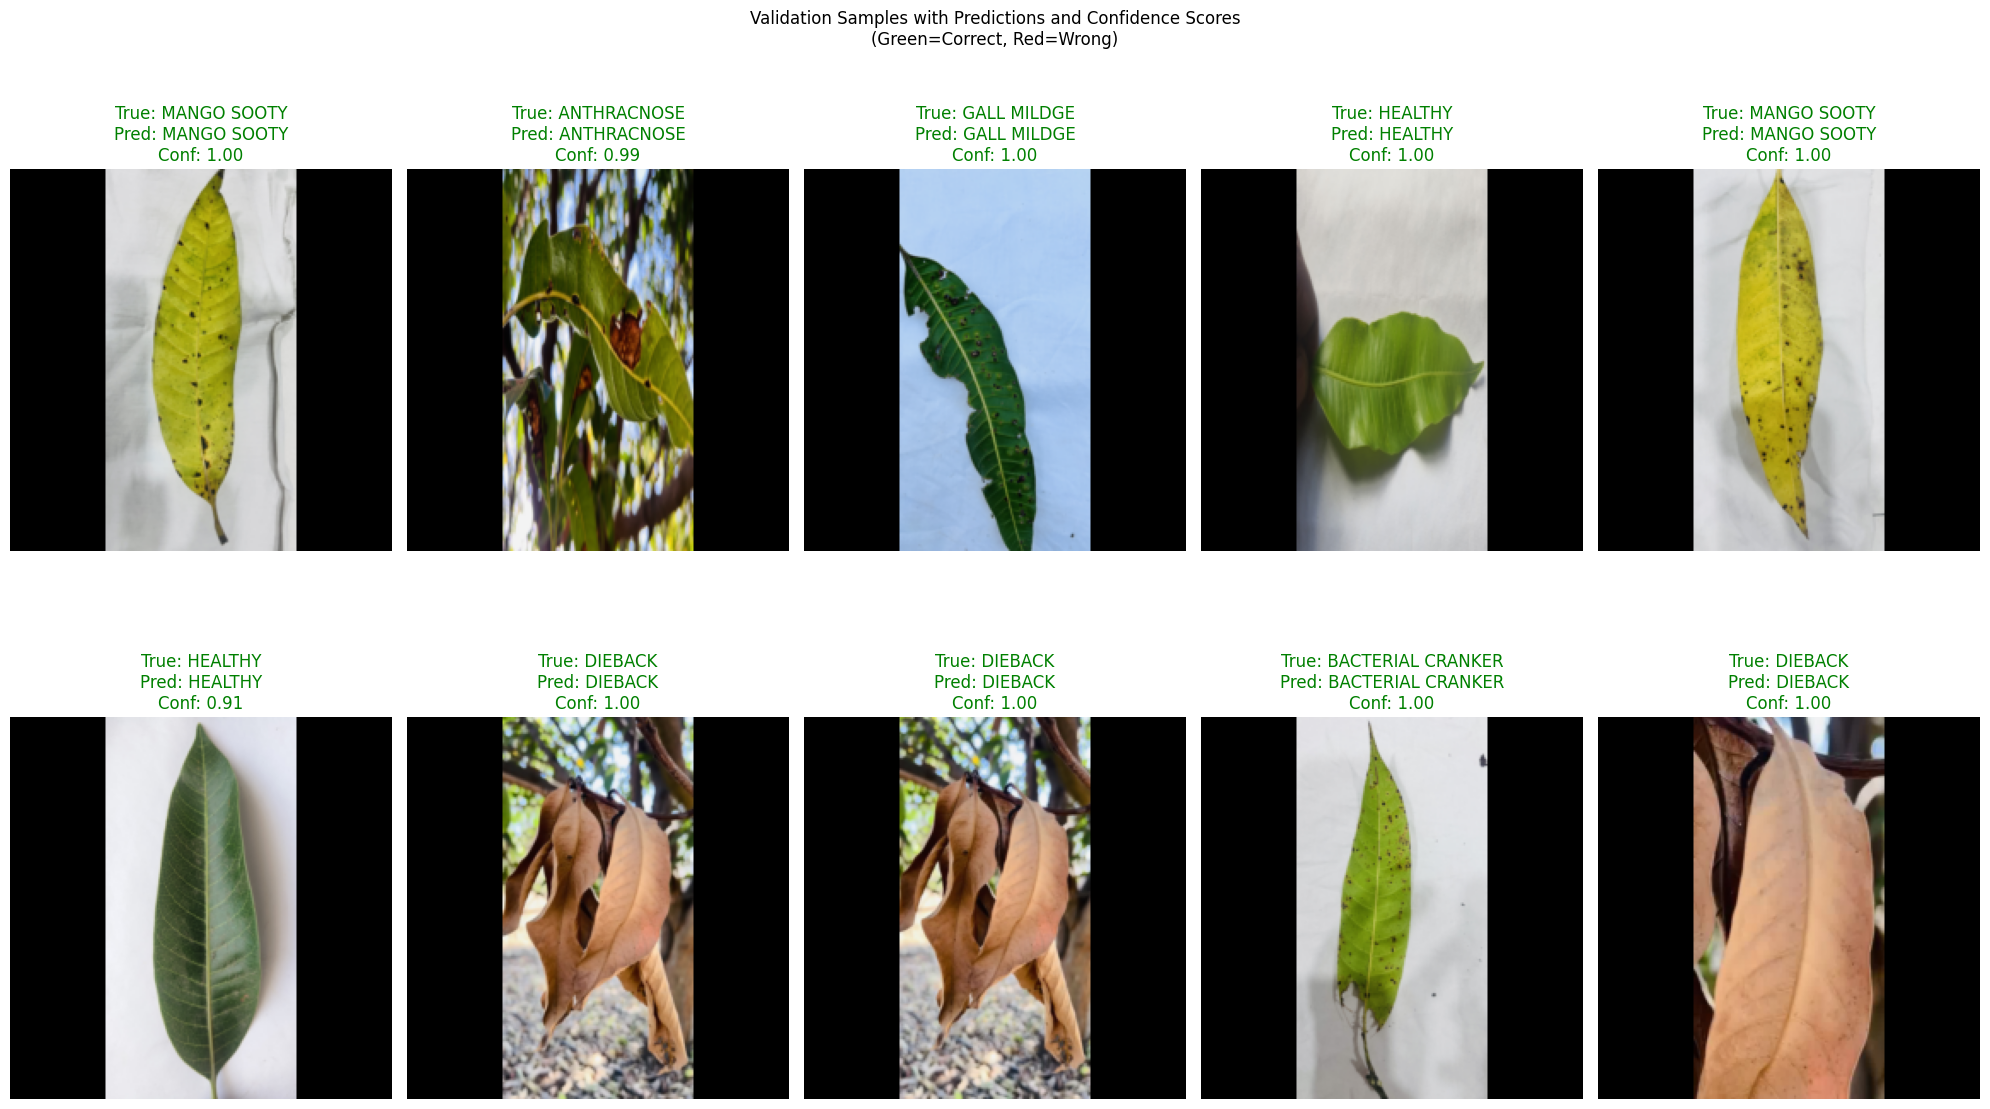

In [22]:
# %% [code]
# Enhanced Version with Confidence Scores
try:
    model.eval()
    
    # Get more samples to ensure we have diverse examples
    samples_to_show = 10
    shown_samples = 0
    fig = plt.figure(figsize=(20, 12))
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            confs, preds = torch.max(probs, 1)
            
            # Convert to CPU for visualization
            images = images.cpu().numpy()
            labels = labels.cpu().numpy()
            preds = preds.cpu().numpy()
            confs = confs.cpu().numpy()
            
            # Plot each image in batch
            for idx in range(len(images)):
                if shown_samples >= samples_to_show:
                    break
                    
                ax = fig.add_subplot(2, 5, shown_samples+1)
                
                # Unnormalize image
                img = images[idx].transpose((1, 2, 0))
                img = img * np.array([0.5, 0.5, 0.5]) + np.array([0.5, 0.5, 0.5])
                img = np.clip(img, 0, 1)
                
                # Display image
                ax.imshow(img)
                
                # Set title with additional info
                true_label = class_names[labels[idx]]
                pred_label = class_names[preds[idx]]
                confidence = confs[idx]
                
                color = 'green' if labels[idx] == preds[idx] else 'red'
                title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}"
                ax.set_title(title, color=color)
                ax.axis('off')
                
                shown_samples += 1
                
            if shown_samples >= samples_to_show:
                break
    
    plt.tight_layout()
    plt.suptitle('Validation Samples with Predictions and Confidence Scores\n(Green=Correct, Red=Wrong)', y=1.02)
    plt.show()

except Exception as e:
    print(f"Error displaying validation images: {str(e)}")

In [25]:
# %% [code]
# Section 8: Save Model
try:
    torch.save(model.state_dict(), 'mango_vit_model.pth')
    print("Model saved successfully")
except Exception as e:
    print(f"Error saving model: {str(e)}")

Model saved successfully


In [26]:
import os
import subprocess
from IPython.display import FileLink, display

def download_file(path, download_file_name):
    os.chdir('/kaggle/working/')
    zip_name = f"/kaggle/working/{download_file_name}.zip"
    command = f"zip {zip_name} {path} -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print("Unable to run zip command!")
        print(result.stderr)
        return
    display(FileLink(f'{download_file_name}.zip'))

download_file('/kaggle/working', 'vitfinal')

/kaggle/working/vitfinal.zip